## Aula 5 — Transformers e Contexto

Este notebook foi projetado para tornar **visível** o funcionamento de modelos Transformer, conectando diretamente a teoria da Aula 5 com experimentos práticos e comparações com a análise sintática (Aula 4).

### Objetivos

1. Executar um modelo Transformer pré-treinado (BERT).
2. Entender o que é tokenização por subpalavras (WordPiece) e por que ela importa.
3. Extrair e **visualizar mapas de atenção** (*self-attention*) como *heatmaps*.
4. Interpretar atenção como uma **distribuição contínua de relevância** (em contraste com grafos discretos).
5. Comparar a atenção com a **dependência sintática** produzida por parsers (spaCy).
6. Observar como o **contexto** reduz ambiguidade em frases reais.

> **Nota didática:** não treinaremos um Transformer do zero. Isso exigiria infraestrutura e tempo incompatíveis com uma aula prática. Em vez disso, usaremos um modelo **pré-treinado**, que é a forma mais comum de uso em aplicações reais.


### 1. Preparação do ambiente

Nesta seção, instalaremos as bibliotecas necessárias e importaremos os módulos usados no restante do notebook.

- `transformers` e `torch`: execução do modelo BERT e extração das atenções.
- `matplotlib` e `seaborn`: visualização em *heatmaps*.
- `spacy`: comparação com análise sintática explícita (Aula 4).

In [1]:
# Instalação das bibliotecas necessárias
!pip install transformers torch matplotlib seaborn spacy -q

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertModel


In [4]:
!pip -q install spacy
!python -m spacy download pt_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 73.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### 2. Relembrando o problema da ambiguidade (ponte com a Aula 4)

Considere a frase:

> *“O homem viu o telescópio.”*

Essa frase é útil porque permite leituras distintas, dependendo do contexto:

- Leitura A: o homem usou um telescópio para ver algo (telescópio = instrumento).
- Leitura B: o homem viu (observou) um telescópio (telescópio = objeto observado).

Na Aula 4, a análise sintática tenta escolher uma estrutura (um grafo de dependência) como “melhor” hipótese.
Na Aula 5, o Transformer não produz um grafo discreto por padrão; ele produz **pesos contínuos** de atenção.

A pergunta prática agora é:

> *O que muda quando trocamos “flechas” por “pesos”?*


### 3. Carregando um Transformer pré-treinado (BERT)

Usaremos o BERT Multilingual Cased. Ele é bidirecional (usa contexto dos dois lados) e expõe os tensores de atenção quando configurado com `output_attentions=True`.

> Para fins didáticos, o foco aqui é: ver a atenção e interpretá-la, não otimizar desempenho.


In [5]:
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
model = BertModel.from_pretrained(
    "bert-base-multilingual-cased",
    output_attentions=True
)

model.eval()
print("Modelo carregado!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Modelo carregado!


### 4. Tokenização: por que o modelo “não vê” palavras (WordPiece)

Antes de analisar o mecanismo de atenção, é fundamental compreender **como o modelo representa o texto**. Diferentemente das abordagens clássicas de PLN, modelos como o BERT **não operam diretamente sobre palavras**, mas sobre unidades menores chamadas **subpalavras** (*subword tokens*).

O BERT utiliza um algoritmo de tokenização denominado **WordPiece**. A ideia central é: em vez de manter um vocabulário enorme com todas as palavras possíveis, o modelo aprende um conjunto finito de fragmentos frequentes e os combina para representar palavras completas. Isso permite lidar bem com:

- palavras raras ou inexistentes no vocabulário (OOV),
- variações morfológicas (plural, gênero, flexão verbal),
- termos técnicos, neologismos e nomes próprios.

Quando uma palavra inteira não está presente no vocabulário, o WordPiece a decompõe em subpartes conhecidas. Tokens iniciados com o prefixo `##` indicam **continuação de uma palavra anterior**.

Além disso, o modelo introduz tokens especiais que **não pertencem à língua natural**, mas têm função estrutural:
- `[CLS]`: representa a sentença como um todo (muito usado em classificação);
- `[SEP]`: marca o fim da sentença (ou separa sentenças).

> Ponto crucial: o mecanismo de atenção opera **sobre tokens/subpalavras**, não sobre “palavras” no sentido tradicional. Por isso, uma palavra como “telescópio” pode aparecer fragmentada em várias unidades, cada uma com sua própria atenção.


In [17]:
sentence = "O homem viu o telescópio"
# Converte a frase em IDs numéricos compreensíveis pelo modelo
inputs = tokenizer(sentence, return_tensors="pt")
# Reconverte esses IDs em tokens textuais internos do modelo para inspeção
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
# Esses tokens não são palavras, e sim unidades sublexicais
tokens

{'input_ids': tensor([[  101,   152, 40066, 39606,   183, 56142, 31505, 10443, 22196,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


['[CLS]', 'O', 'homem', 'viu', 'o', 'tele', '##sc', '##ó', '##pio', '[SEP]']

### 5. Executando o modelo e visualizando as atenções

Transformers como o BERT são organizados em **múltiplas camadas (*layers*)** e, em cada camada, várias **cabeças de atenção (*attention heads*)**.

- **Camadas (layers)**: níveis sucessivos de processamento. Em geral, camadas mais altas tendem a incorporar contexto mais global.
- **Cabeças (heads)**: “perspectivas” paralelas. Cada cabeça aprende um padrão próprio de comparação entre tokens (por meio de projeções distintas de Q, K e V).

Neste notebook, vamos:

1. executar o modelo para obter as matrizes de atenção;
2. selecionar **a última camada** (índice `num_layers - 1`);
3. **visualizar todas as cabeças dessa camada**, em uma grade de *heatmaps*.

> Cada par *(camada, cabeça)* gera uma matriz de atenção diferente.  
> Não existe uma “cabeça do sujeito” ou “cabeça do objeto” fixa: os padrões são aprendidos e podem variar conforme o modelo e a frase.


In [39]:
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # lista: [num_layers] cada item: (batch, heads, seq, seq)
num_layers = len(attentions)
num_heads = attentions[0].shape[1]

layer_idx = num_layers - 1  # última camada (explícito, evita índice negativo)

print(f"Camadas: {num_layers}")
print(f"Cabeças por camada: {num_heads}")
print(f"Camada selecionada para visualização: {layer_idx}")


Camadas: 12
Cabeças por camada: 12
Camada selecionada para visualização: 11


### 6. Visualização: mapas de calor da atenção (heatmaps)

Podemos ler a matriz de atenção assim:

> Para cada token (linha), quanto ele “consulta” os demais tokens (colunas) para construir sua representação contextual?

- **Linhas**: token em foco (Query) — o token cuja representação está sendo atualizada.
- **Colunas**: tokens consultados (Keys/Values).
- **Valores**: pesos normalizados (via *softmax*) — em cada linha, os pesos tendem a somar aproximadamente 1.

A seguir, vamos visualizar **todas as cabeças da última camada** em uma grade (3 por linha).  
Além das cores, exibiremos o **valor numérico em cada célula (duas casas decimais)** para reforçar que a atenção é contínua (não binária).



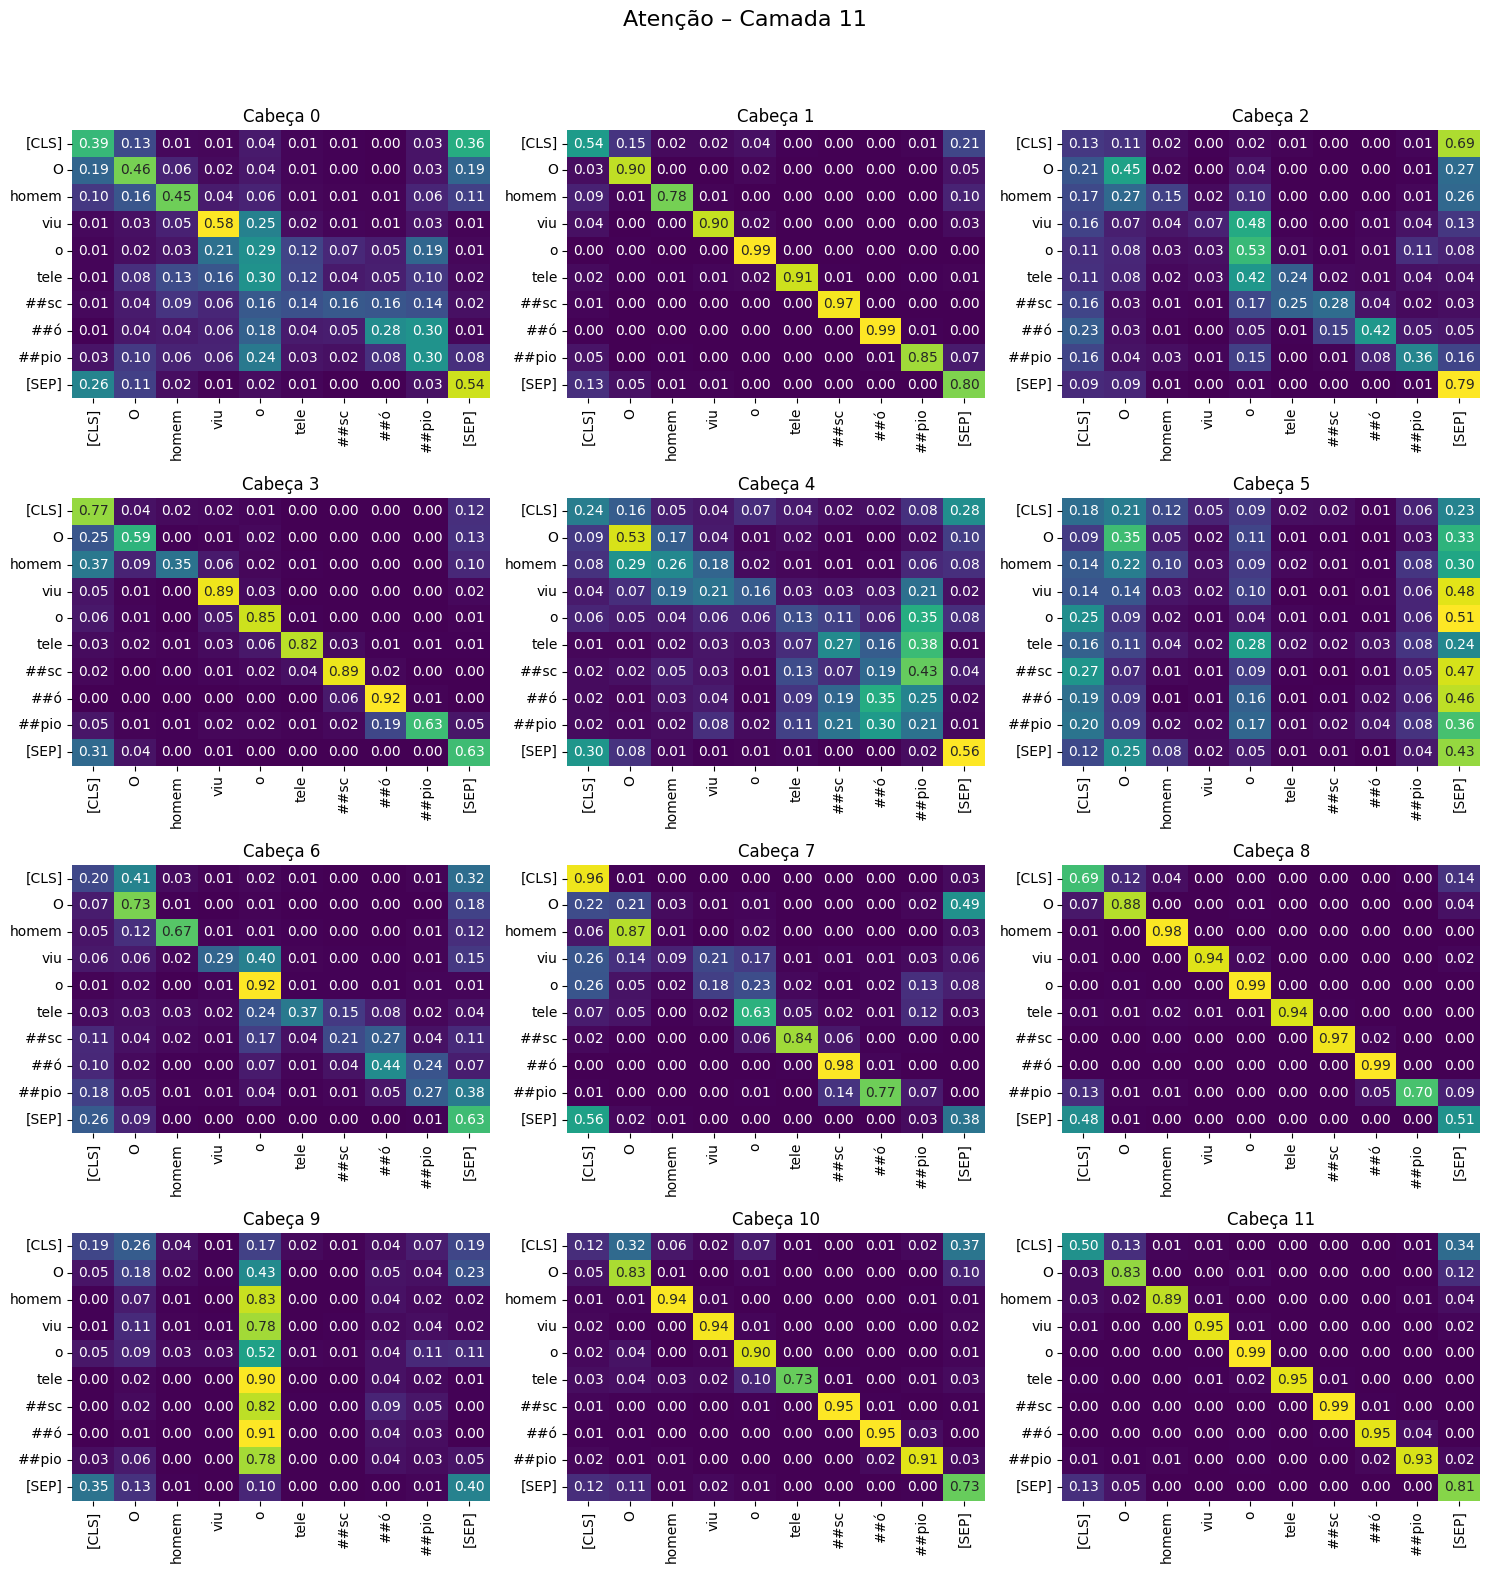

In [25]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # [num_layers][batch, heads, seq, seq]
layer_idx = len(attentions) - 1 # última camada (mais contextual)

num_heads = attentions[0].shape[1]
heads_per_row = 3
num_rows = math.ceil(num_heads / heads_per_row)

fig, axes = plt.subplots(
    num_rows,
    heads_per_row,
    figsize=(5 * heads_per_row, 4 * num_rows)
)

# Garante que axes seja sempre 2D
axes = axes.reshape(num_rows, heads_per_row)

for head_idx in range(num_heads):
    row = head_idx // heads_per_row
    col = head_idx % heads_per_row

    attention_matrix = attentions[layer_idx][0][head_idx].cpu().numpy()

    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        cbar=False,
        annot=True,
        fmt=".2f",
        ax=axes[row, col]
    )

    axes[row, col].set_title(f"Cabeça {head_idx}")

# Remove subplots vazios (se o número de cabeças não for múltiplo de 3)
for idx in range(num_heads, num_rows * heads_per_row):
    row = idx // heads_per_row
    col = idx % heads_per_row
    axes[row, col].axis("off")

plt.suptitle(f"Atenção – Camada {layer_idx}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

⚠️ Atenção: no heatmap, tanto linhas quanto colunas representam tokens.
A diferença é direcional: a linha “olha”, a coluna é “olhada”.


Os valores exibidos em cada célula representam o **peso de atenção** atribuído
entre dois tokens. Quanto maior o valor, maior a influência de um token sobre o outro
no processo de contextualização.



> Não existe um conteúdo fixo e pré-definido em cada cabeça 0 a 11. As cabeças não têm papéis nomeados, não correspondem a categorias linguísticas rígidas e podem variar de modelo para modelo e até de frase para frase.

Formalmente, cada cabeça é apenas:  
- um conjunto independente de matrizes Q (Query), K (Key) e V (Value),
- aprendidas durante o treinamento,
- que projetam os mesmos embeddings de entrada em subespaços diferentes.  

Cada cabeça aprende uma forma diferente de comparar tokens entre si.
Embora não haja garantia, estudos empíricos mostram tendências recorrentes, especialmente em camadas intermediárias e finais.
Em modelos como o BERT-base (12 cabeças), é comum observar padrões aproximados como:

| Cabeça (exemplo) | Tendência frequente (não garantida) |
| :--------------- | :---------------------------------- |
| 0–2              | Atenção local (tokens vizinhos)     |
| 3–4              | Relações sintáticas simples (verbo ↔ argumento) |
| 5–6              | Modificadores nominais              |
| 7–8              | Dependências de longo alcance      |
| 9–10             | Relações semânticas difusas         |
| 11               | Atenção quase global ou pouco estruturada |


### 7. Comparação com spaCy (Aula 4): dependência sintática explícita

Nesta seção, vamos gerar uma análise de dependência com spaCy para comparar com o que já observamos nos mapas de atenção do Transformer (Seção 6).

- spaCy (Aula 4): produz relações **discretas e rotuladas** (cada token tem um `head` e um rótulo `dep_`).
- Transformer (Aula 5): produz **distribuições contínuas de pesos** (atenção), visualizadas nos heatmaps gerados anteriormente para a mesma frase.


In [10]:
import spacy
nlp = spacy.load("pt_core_news_sm")

doc = nlp(sentence)
for token in doc:
    print(f"{token.text:12} | dep={token.dep_:10} | head={token.head.text}")

O            | dep=det        | head=homem
homem        | dep=nsubj      | head=viu
viu          | dep=ROOT       | head=viu
o            | dep=det        | head=telescópio
telescópio   | dep=obj        | head=viu


### 8. Experimento de contexto: resolvendo ambiguidade por atenção

Agora, vamos testar uma frase com ambiguidade lexical:

> **“O banco estava fechado porque era feriado.”**

A palavra **“banco”** pode significar “instituição financeira” ou “assento”, mas o contexto (“fechado”, “feriado”) tende a puxar para instituição.

#### Tarefa
1. Tokenize a frase e inspecione os tokens (subpalavras).
2. Execute o modelo e extraia as atenções.
3. Visualize **todas as cabeças da última camada** (mesmo procedimento da Seção 6).
4. Procure cabeças em que o token “banco” (ou subpalavra correspondente) apresente atenção relativamente alta para palavras de contexto como “fechado” e “feriado”.

> **Extensão (opcional):** altere a frase para induzir outro sentido, por exemplo:  
> “O banco estava molhado porque choveu.”


In [46]:
sentence2 = "O banco estava fechado porque era feriado"
inputs2 = tokenizer(sentence2, return_tensors="pt")
tokens2 = tokenizer.convert_ids_to_tokens(inputs2["input_ids"][0])

with torch.no_grad():
    outputs2 = model(**inputs2)

att2 = outputs2.attentions  # [num_layers][batch, heads, seq, seq]

print("Tokens da frase 2:")
tokens2

Tokens da frase 2:


['[CLS]',
 'O',
 'banco',
 'estava',
 'fecha',
 '##do',
 'porque',
 'era',
 'fer',
 '##iado',
 '[SEP]']

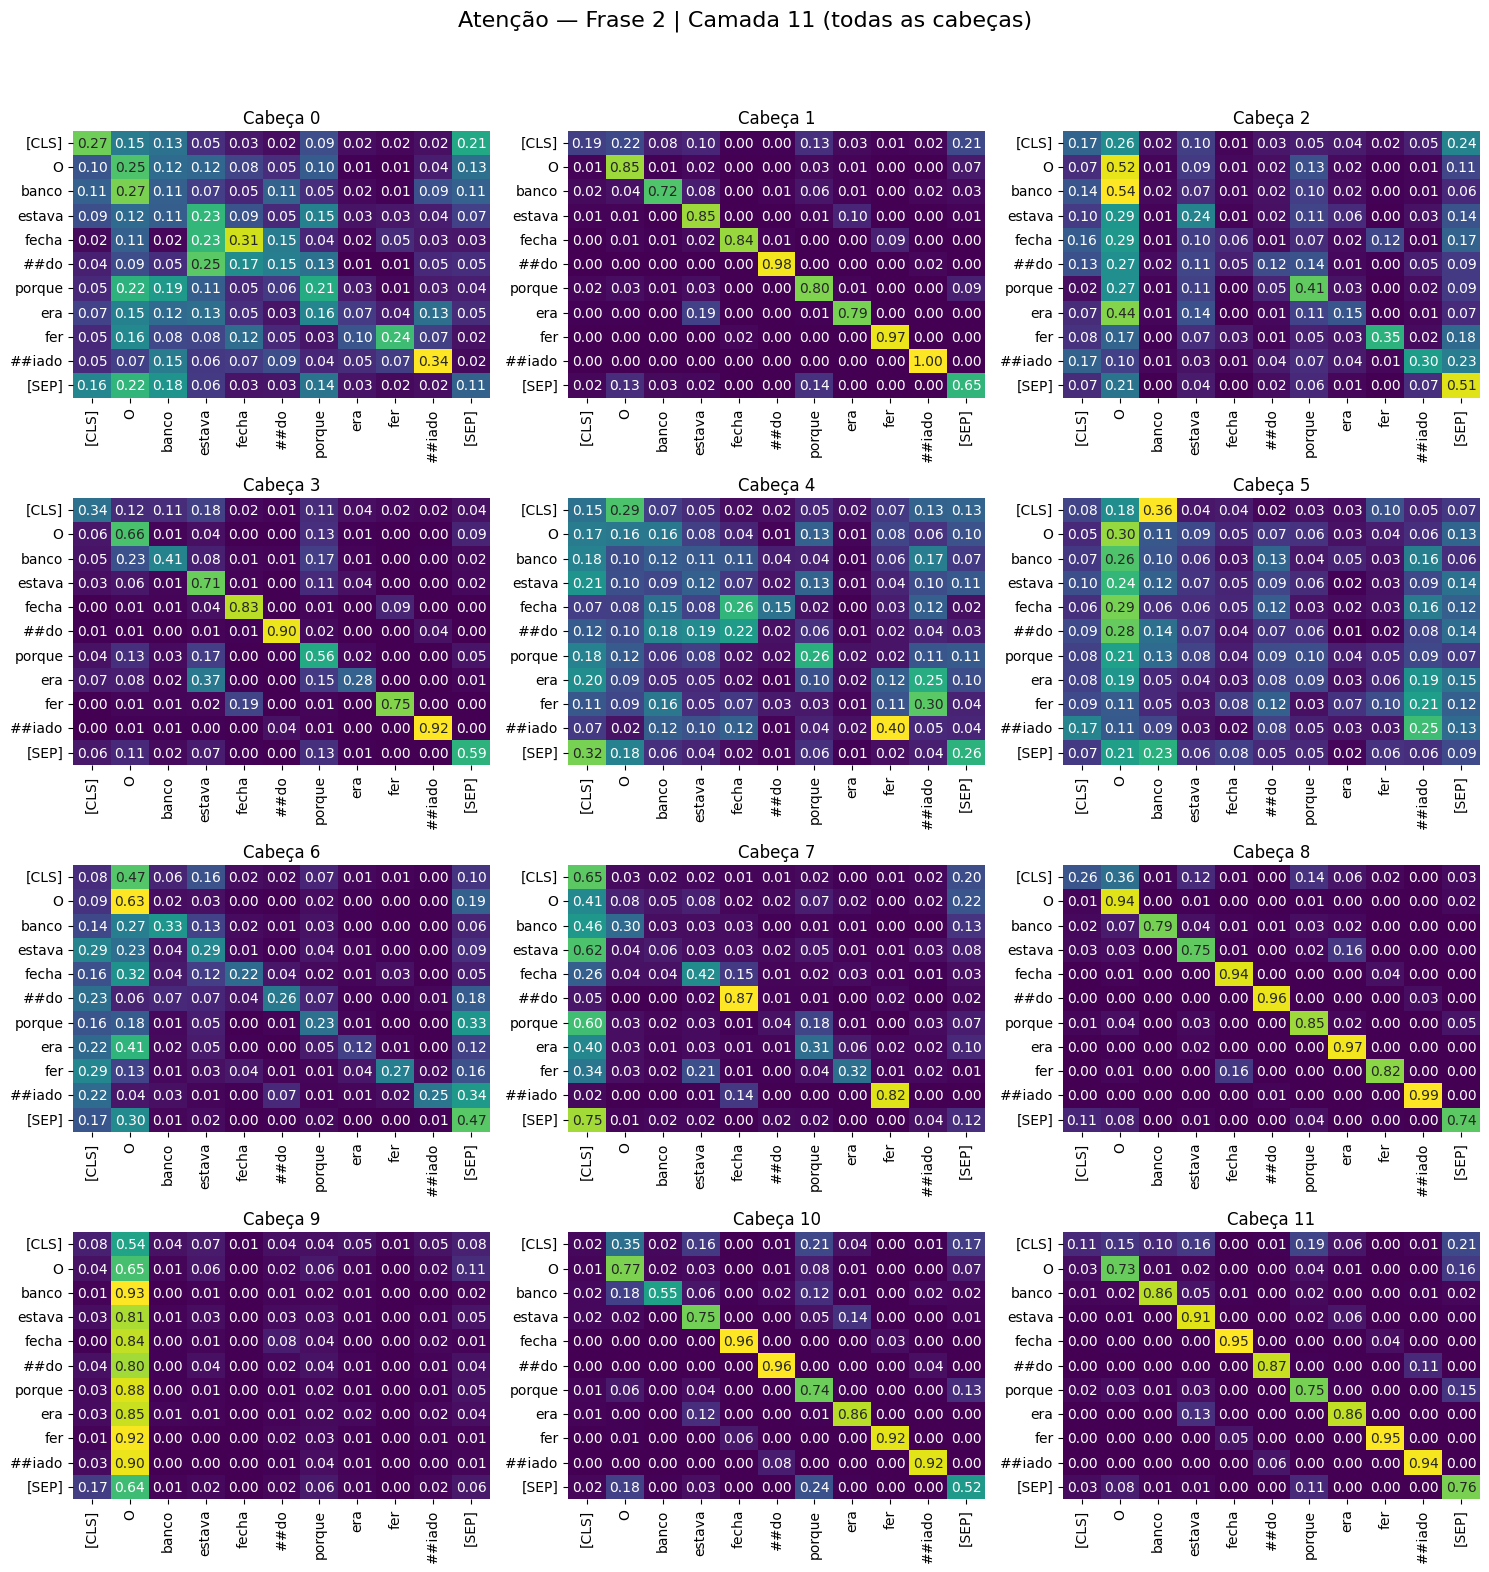

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Usamos a mesma camada final, mas agora a lista de atenções é a da frase 2
num_layers2 = len(att2)
num_heads2 = att2[0].shape[1]
layer_idx2 = num_layers2 - 1

heads_per_row = 3
num_rows2 = math.ceil(num_heads2 / heads_per_row)

fig, axes = plt.subplots(
    num_rows2,
    heads_per_row,
    figsize=(5 * heads_per_row, 4 * num_rows2)
)

axes = axes.reshape(num_rows2, heads_per_row)

for head_idx in range(num_heads2):
    row = head_idx // heads_per_row
    col = head_idx % heads_per_row

    attention_matrix2 = att2[layer_idx2][0][head_idx].cpu().numpy()

    sns.heatmap(
        attention_matrix2,
        xticklabels=tokens2,
        yticklabels=tokens2,
        cmap="viridis",
        cbar=False,
        annot=True,
        fmt=".2f",
        ax=axes[row, col]
    )

    axes[row, col].set_title(f"Cabeça {head_idx}")

for idx in range(num_heads2, num_rows2 * heads_per_row):
    row = idx // heads_per_row
    col = idx % heads_per_row
    axes[row, col].axis("off")

plt.suptitle(f"Atenção — Frase 2 | Camada {layer_idx2} (todas as cabeças)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Como interpretar os mapas de atenção (leitura correta)

Ao observar os mapas de atenção da última camada, é comum esperar ver uma ligação clara entre
“banco” e “feriado”, já que a frase é semanticamente desambiguada. No entanto, essa ligação
**nem sempre aparece de forma explícita** — e isso é esperado.

O mecanismo de atenção **não é um grafo de explicação linguística**. Ele serve para combinar
informações entre tokens, e não para produzir árvores sintáticas ou relações semânticas
claramente identificáveis.

Além disso:
- o modelo trabalha com **subpalavras** (WordPiece), e não com palavras inteiras;
- o significado é representado de forma **distribuída**, ao longo de várias cabeças e camadas;
- muitas cabeças da última camada focam em preservar o próprio token ou em padrões locais.

Por isso, a ausência de uma conexão direta “banco → feriado” **não significa que o modelo não
entendeu a frase**. A compreensão emerge da combinação global das atenções, e não de uma única
célula do heatmap.

**Ideia-chave:**  
Os mapas de atenção mostram *como* a informação é combinada internamente, não *por que*
o modelo chegou a uma determinada interpretação. Isso explica por que a análise sintática
explícita (Aula 4) continua importante para interpretação e auditoria.
